### Assignment 5: Comparative Binary Classification with XGBoost
**Name:** Ailibiya Kuerban
**Student ID:** 101039952

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Problem Definition

* Target variable: Bankrupt?
* Positive class: 1 (went bankrupt)
* Why it matters: missing a bankrupt company is worse than a false alarm
* Classes are imbalanced (~3.2% positive)
* Primary metric: PR-AUC
* Calibration metric: Brier score

In [3]:
df = pd.read_csv("../data/data.csv")

## 2. Quick EDA

#### 2.1 Dataset Overview


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (6819, 96)
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    Af

#### 2.2 Target Distribution


Class counts:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class percentages:
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


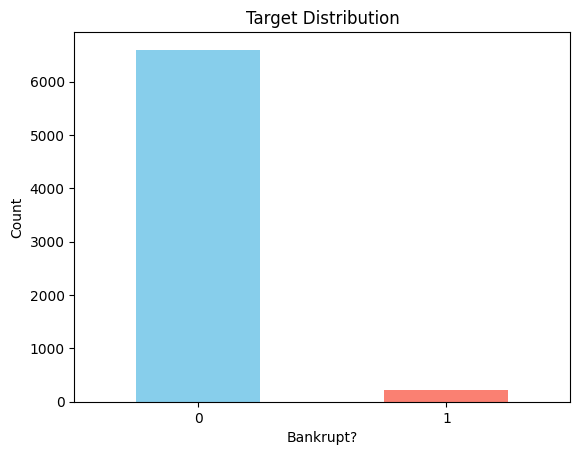

In [5]:
import matplotlib.pyplot as plt

class_counts = df["Bankrupt?"].value_counts().sort_index()
class_percentages = df["Bankrupt?"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(2))

class_counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Target Distribution")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


#### 2.3 Missing Values and Duplicates

In [6]:
missing_per_column = df.isnull().sum()
total_missing = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print("Missing values per column:")
print(missing_per_column)

print("\nTotal missing values:", total_missing)
print("Duplicate row count:", duplicate_count)


Missing values per column:
Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

Total missing values: 0
Duplicate row count: 0


#### 2.4 Key Observation for Modeling
* Only about 3% of companies are bankrupt, so accuracy will not be used as the primary metric.

## 3. Train, Validation, Test Split
* Train = 70%
* Validation = 15%
* Test = 15%
* Use stratified sampling
* Test set is not used until final evaluation

#### 3.1 Split Strategy


In [7]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

# Print class distribution percentages
print("\nClass distribution in training set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution in validation set (%):")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution in test set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


X_train shape: (4773, 95)
X_val shape: (1023, 95)
X_test shape: (1023, 95)

y_train shape: (4773,)
y_val shape: (1023,)
y_test shape: (1023,)

Class distribution in training set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

Class distribution in validation set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

Class distribution in test set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


#### 3.2 Why Stratified Sampling Is Used
* Stratified sampling is used to ensure that the class distribution of the target variable is preserved across the train, validation, and test sets. Since the dataset is highly imbalanced, this helps prevent situations where one split may contain too few or no positive cases, which would negatively affect model training and evaluation.

#### 3.3 Class Balance Across Splits
* The class distribution is consistent across the train, validation, and test sets, with approximately the same percentage of bankrupt companies in each split. This confirms that stratified sampling was applied correctly and ensures that each dataset is representative of the original distribution.

## 4. Preprocessing
* separate features (X) and target (y)
* remove target column from features
* check whether there are categorical features
* handle missing values if needed
* only scale models that need scaling
* briefly check for leakage columns

#### 4.1 Separate Features and Target


In [8]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

* The target column was separated from the feature matrix before model training. The feature matrix is stored in `X`, and the target variable is stored in `y`.

#### 4.2 Data Type Review


In [9]:
# Features only
X = df.drop("Bankrupt?", axis=1)

print("Data type counts:")
print(X.dtypes.value_counts())

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nCategorical columns:")
if categorical_columns:
    print(categorical_columns)
else:
    print("No categorical columns found.")


Data type counts:
float64    93
int64       2
Name: count, dtype: int64

Categorical columns:
No categorical columns found.


* Most features in this dataset are numeric. No special encoding is expected unless categorical columns are found.

#### 4.3 Missing Value Handling


In [10]:
# Check missing values in each split
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_val:", X_val.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

# Fill missing values using training-set median
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("\nAfter imputation:")
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_val:", X_val.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())


Missing values in X_train: 0
Missing values in X_val: 0
Missing values in X_test: 0

After imputation:
Missing values in X_train: 0
Missing values in X_val: 0
Missing values in X_test: 0


* No missing values were found after splitting, so no imputation was needed.

#### 4.4 Leakage Check


In [11]:
print("'Bankrupt?' in X columns:", "Bankrupt?" in X.columns)

print("\nFirst few column names:")
print(X.columns[:10].tolist())


'Bankrupt?' in X columns: False

First few column names:
[' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)']


* A brief leakage check was performed to confirm that the target column was removed from the feature matrix before modeling. No obvious leakage column was identified at this stage.

#### 4.5 Scaling Strategy
* Scaling will only be applied to models that require it. Logistic Regression may benefit from feature scaling, while XGBoost does not require scaling because it is tree-based. Therefore, scaling will not be applied globally to all experiments.

## 5. Feature Sets

#### 5.1 Feature Set A
* Feature Set A includes all usable features after basic preprocessing and cleaning. This serves as the main feature set for the baseline and core XGBoost experiments.

#### 5.2 Feature Set B
* Feature Set B is a reduced set of features selected from the original dataset. It is created to evaluate whether a smaller, more focused set of features can improve model performance or make the model easier to interpret.

#### 5.3 Feature Selection Method

In [12]:
from xgboost import XGBClassifier
import pandas as pd

# Train XGBoost on training data only
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# Get feature importances
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Select top 25 features
top_25_features = feature_importance.head(25).index.tolist()

print("Top 25 selected features:")
print(top_25_features)

# Create Feature Set B
X_train_B = X_train[top_25_features]
X_val_B = X_val[top_25_features]
X_test_B = X_test[top_25_features]

print("\nFeature Set B shapes:")
print("X_train_B:", X_train_B.shape)
print("X_val_B:", X_val_B.shape)
print("X_test_B:", X_test_B.shape)


Top 25 selected features:
[" Net Income to Stockholder's Equity", ' Borrowing dependency', ' Persistent EPS in the Last Four Seasons', ' Total debt/Total net worth', ' Quick Ratio', ' Inventory/Working Capital', ' Interest Coverage Ratio (Interest expense to EBIT)', ' ROA(C) before interest and depreciation before interest', ' Cash Flow to Liability', ' ROA(B) before interest and depreciation after tax', ' Total Asset Return Growth Rate Ratio', ' Net Value Per Share (A)', ' Accounts Receivable Turnover', ' Total income/Total expense', ' Cash flow rate', ' Retained Earnings to Total Assets', ' Operating Funds to Liability', ' Working Capital/Equity', ' Long-term Liability to Current Assets', ' Equity to Long-term Liability', ' Long-term fund suitability ratio (A)', ' Non-industry income and expenditure/revenue', ' Current Assets/Total Assets', ' Operating profit per person', ' Realized Sales Gross Profit Growth Rate']

Feature Set B shapes:
X_train_B: (4773, 25)
X_val_B: (1023, 25)
X_te

* Feature Set B was selected using XGBoost feature importance on the training set only.
* The top 25 features were kept for the smaller feature set.
* This smaller feature set will be compared against Feature Set A in Experiment 5.
* A reduced feature set may be easier to explain and may reduce noise.

## 6. Evaluation Framework
* This assignment evaluates models using both discrimination and calibration metrics. `PR-AUC` is used as the primary discrimination metric because the positive class is rare, and `Brier score` is used to assess the quality of predicted probabilities. Additional metrics such as `ROC-AUC`, `precision`, `recall`, and `F1-score` are also reported for comparison. To keep the experiments consistent, a reusable evaluation function is used for all models.

In [13]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
)

def evaluate_model(model, X_train, y_train, X_val, y_val):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict probabilities
    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]
    
    # Convert probabilities to class predictions using threshold = 0.5
    val_preds = (val_probs >= 0.5).astype(int)
    
    # Compute metrics
    train_pr_auc = average_precision_score(y_train, train_probs)
    val_pr_auc = average_precision_score(y_val, val_probs)
    val_roc_auc = roc_auc_score(y_val, val_probs)
    val_brier = brier_score_loss(y_val, val_probs)
    val_precision = precision_score(y_val, val_preds)
    val_recall = recall_score(y_val, val_preds)
    val_f1 = f1_score(y_val, val_preds)
    overfit_gap = train_pr_auc - val_pr_auc
    
    # Return results
    return {
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc,
        "val_brier": val_brier,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "overfit_gap": overfit_gap
    }


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

results = evaluate_model(model, 
                         X_train,
                         y_train, 
                         X_val, 
                         y_val)

for k, v in results.items():
    print(f"{k}: {v:.4f}")

train_pr_auc: 0.0611
val_pr_auc: 0.0434
val_roc_auc: 0.5866
val_brier: 0.0433
val_precision: 0.0000
val_recall: 0.0000
val_f1: 0.0000
overfit_gap: 0.0177


* The overfitting gap is defined as training PR-AUC minus validation PR-AUC. A larger gap may indicate that the model is fitting the training data too closely.

## 7. Experiments 

In [15]:
results_table = []

#### 7.1 Experiment 1: Simple Baseline Model

In [16]:
from sklearn.linear_model import LogisticRegression

# Experiment 1: Logistic Regression baseline
model = LogisticRegression(max_iter=1000)

results_exp1 = evaluate_model(model, X_train, y_train, X_val, y_val)

results_exp1.update({
    "exp_id": 1,
    "model": "Logistic Regression",
    "feature_set": "A",
    "main_settings": "max_iter=1000",
    "threshold": 0.5,
    "selected_finalist": "No",
    "notes": "Simple baseline model"
})

results_exp1


{'train_pr_auc': 0.06106093126668735,
 'val_pr_auc': 0.04340783193388542,
 'val_roc_auc': 0.5865625956535048,
 'val_brier': 0.04326834989831102,
 'val_precision': 0.0,
 'val_recall': 0.0,
 'val_f1': 0.0,
 'overfit_gap': 0.01765309933280193,
 'exp_id': 1,
 'model': 'Logistic Regression',
 'feature_set': 'A',
 'main_settings': 'max_iter=1000',
 'threshold': 0.5,
 'selected_finalist': 'No',
 'notes': 'Simple baseline model'}

In [17]:
results_table.append(results_exp1)

#### 7.2 Experiment 2: XGBoost Baseline

In [18]:
from xgboost import XGBClassifier

# Experiment 2: Baseline XGBoost
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

results_exp2 = evaluate_model(model, X_train, y_train, X_val, y_val)

results_exp2.update({
    "exp_id": 2,
    "model": "XGBoost Baseline",
    "feature_set": "A",
    "main_settings": "default settings",
    "threshold": 0.5,
    "selected_finalist": "No",
    "notes": "Baseline XGBoost with all features"
})

results_exp2


{'train_pr_auc': 0.9999999999999999,
 'val_pr_auc': 0.4888902436480737,
 'val_roc_auc': 0.9527089072543617,
 'val_brier': 0.02381926402449608,
 'val_precision': 0.625,
 'val_recall': 0.30303030303030304,
 'val_f1': 0.40816326530612246,
 'overfit_gap': 0.5111097563519262,
 'exp_id': 2,
 'model': 'XGBoost Baseline',
 'feature_set': 'A',
 'main_settings': 'default settings',
 'threshold': 0.5,
 'selected_finalist': 'No',
 'notes': 'Baseline XGBoost with all features'}

In [19]:
results_table.append(results_exp2)

#### 7.3 Experiment 3: XGBoost with Imbalance Handling

In [20]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [21]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

# Experiment 3: XGBoost with class imbalance handling
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

results_exp3 = evaluate_model(model, X_train, y_train, X_val, y_val)

results_exp3.update({
    "exp_id": 3,
    "model": "XGBoost Imbalance",
    "feature_set": "A",
    "main_settings": "scale_pos_weight",
    "threshold": 0.5,
    "selected_finalist": "No",
    "notes": "Handled class imbalance with scale_pos_weight"
})

results_exp3


{'train_pr_auc': 0.9999999999999999,
 'val_pr_auc': 0.49448829985833814,
 'val_roc_auc': 0.9581573308846036,
 'val_brier': 0.023837953805923462,
 'val_precision': 0.5454545454545454,
 'val_recall': 0.36363636363636365,
 'val_f1': 0.43636363636363634,
 'overfit_gap': 0.5055117001416618,
 'exp_id': 3,
 'model': 'XGBoost Imbalance',
 'feature_set': 'A',
 'main_settings': 'scale_pos_weight',
 'threshold': 0.5,
 'selected_finalist': 'No',
 'notes': 'Handled class imbalance with scale_pos_weight'}

In [22]:
results_table.append(results_exp3)

#### 7.4 Experiment 4: Lightly Tuned XGBoost

In [23]:
from xgboost import XGBClassifier

# Experiment 4: Lightly tuned XGBoost with Feature Set A
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

results_exp4 = evaluate_model(model, X_train, y_train, X_val, y_val)

results_exp4.update({
    "exp_id": 4,
    "model": "XGBoost Tuned",
    "feature_set": "A",
    "main_settings": "n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8",
    "threshold": 0.5,
    "selected_finalist": "No",
    "notes": "Lightly tuned XGBoost"
})

results_exp4


{'train_pr_auc': 0.9999999999999999,
 'val_pr_auc': 0.5979945961628919,
 'val_roc_auc': 0.9646158555249464,
 'val_brier': 0.020135773345828056,
 'val_precision': 0.6923076923076923,
 'val_recall': 0.2727272727272727,
 'val_f1': 0.391304347826087,
 'overfit_gap': 0.40200540383710803,
 'exp_id': 4,
 'model': 'XGBoost Tuned',
 'feature_set': 'A',
 'main_settings': 'n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8',
 'threshold': 0.5,
 'selected_finalist': 'No',
 'notes': 'Lightly tuned XGBoost'}

In [24]:
results_table.append(results_exp4)

#### 7.5 Experiment 5: XGBoost with Selected Features

In [25]:
from xgboost import XGBClassifier

# Experiment 5: Tuned XGBoost with Feature Set B
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

results_exp5 = evaluate_model(model, X_train_B, y_train, X_val_B, y_val)

results_exp5.update({
    "exp_id": 5,
    "model": "XGBoost Selected Features",
    "feature_set": "B",
    "main_settings": "tuned XGBoost with top 25 features",
    "threshold": 0.5,
    "selected_finalist": "No",
    "notes": "Used Feature Set B"
})

results_exp5


{'train_pr_auc': 0.9923489767688224,
 'val_pr_auc': 0.45718271836396956,
 'val_roc_auc': 0.9516069788797061,
 'val_brier': 0.02202836610376835,
 'val_precision': 0.6,
 'val_recall': 0.36363636363636365,
 'val_f1': 0.4528301886792453,
 'overfit_gap': 0.5351662584048529,
 'exp_id': 5,
 'model': 'XGBoost Selected Features',
 'feature_set': 'B',
 'main_settings': 'tuned XGBoost with top 25 features',
 'threshold': 0.5,
 'selected_finalist': 'No',
 'notes': 'Used Feature Set B'}

In [26]:
results_table.append(results_exp5)

In [27]:
results_df = pd.DataFrame(results_table)
results_df["selected_finalist"] = "No"
results_df.loc[results_df["exp_id"] == 4, "selected_finalist"] = "Yes"
results_df = results_df[
    [
        "exp_id",
        "model",
        "feature_set",
        "main_settings",
        "train_pr_auc",
        "val_pr_auc",
        "overfit_gap",
        "val_roc_auc",
        "val_brier",
        "threshold",
        "val_precision",
        "val_recall",
        "val_f1",
        "selected_finalist",
        "notes"
    ]
]

results_df

,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1,selected_finalist,notes
0,1,Logistic Regression,A,max_iter=1000,0.061061,0.043408,0.017653,0.586563,0.043268,0.5,0.000000,0.000000,0.000000,No,Simple baseline model
1,2,XGBoost Baseline,A,default settings,1.000000,0.488890,0.511110,0.952709,0.023819,0.5,0.625000,0.303030,0.408163,No,Baseline XGBoost with all features
2,3,XGBoost Imbalance,A,scale_pos_weight,1.000000,0.494488,0.505512,0.958157,0.023838,0.5,0.545455,0.363636,0.436364,No,Handled class imbalance with scale_pos_weight
3,4,XGBoost Tuned,A,"n_estimators=200, max_depth=4, learning_rate=0...",1.000000,0.597995,0.402005,0.964616,0.020136,0.5,0.692308,0.272727,0.391304,Yes,Lightly tuned XGBoost
4,5,XGBoost Selected Features,B,tuned XGBoost with top 25 features,0.992349,0.457183,0.535166,0.951607,0.022028,0.5,0.600000,0.363636,0.452830,No,Used Feature Set B


## 8. Required Metrics

* PR-AUC is used as the primary discrimination metric because it focuses on performance for the rare positive class (bankrupt companies).
* Brier score is used to evaluate the quality of predicted probabilities (calibration).
* Accuracy is not used as a primary metric due to class imbalance.
* Additional metrics such as ROC-AUC, precision, recall, and F1-score are reported for context.

## 9. Threshold Selection

* Threshold selection is performed after choosing the final model.

* The tuned XGBoost model (Experiment 4) was selected based on the highest validation PR-AUC and strong overall performance.

* For this assignment, a default threshold of **0.5** was used as a simple baseline.

* This threshold provides a balanced tradeoff between precision and recall and keeps the evaluation consistent across models.

* Since missing a bankrupt company (false negative) is more costly than incorrectly flagging a healthy company, a lower threshold could improve recall. However, to keep the approach simple and avoid overfitting to the validation set, the default threshold was retained.

* The same threshold will be used when evaluating the final model on the test set.

## 10. Results Table

In [28]:
results_df

,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1,selected_finalist,notes
0,1,Logistic Regression,A,max_iter=1000,0.061061,0.043408,0.017653,0.586563,0.043268,0.5,0.000000,0.000000,0.000000,No,Simple baseline model
1,2,XGBoost Baseline,A,default settings,1.000000,0.488890,0.511110,0.952709,0.023819,0.5,0.625000,0.303030,0.408163,No,Baseline XGBoost with all features
2,3,XGBoost Imbalance,A,scale_pos_weight,1.000000,0.494488,0.505512,0.958157,0.023838,0.5,0.545455,0.363636,0.436364,No,Handled class imbalance with scale_pos_weight
3,4,XGBoost Tuned,A,"n_estimators=200, max_depth=4, learning_rate=0...",1.000000,0.597995,0.402005,0.964616,0.020136,0.5,0.692308,0.272727,0.391304,Yes,Lightly tuned XGBoost
4,5,XGBoost Selected Features,B,tuned XGBoost with top 25 features,0.992349,0.457183,0.535166,0.951607,0.022028,0.5,0.600000,0.363636,0.452830,No,Used Feature Set B


* The table above summarizes the performance of all five experiments.

* The Logistic Regression baseline performed poorly due to the highly imbalanced dataset.

* All XGBoost models significantly outperformed the baseline, showing much stronger ability to distinguish between bankrupt and non-bankrupt companies.

* Handling class imbalance improved recall, while light tuning further improved overall performance.

* The tuned XGBoost model (Experiment 4) achieved the highest validation PR-AUC and best overall balance of metrics, and was therefore selected as the final model.

* Using a smaller feature set slightly reduced performance but made the model simpler and easier to interpret.

## 11. Final Test Evaluation

In [29]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
)

# Final Test Evaluation
# Recreate and train the selected final model (Experiment 4)
final_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
final_model.fit(X_train, y_train)

threshold = 0.5

# 1. Predicted probabilities for the positive class
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# 2. Convert probabilities to class predictions using the chosen threshold
y_test_pred = (y_test_proba >= threshold).astype(int)

# 3. Calculate final test metrics
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_brier = brier_score_loss(y_test, y_test_proba)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

# 4. Print results clearly
print("Final Test Evaluation (Selected Model: Experiment 4)")
print(f"Threshold: {threshold}")
print(f"PR-AUC:     {test_pr_auc:.4f}")
print(f"ROC-AUC:    {test_roc_auc:.4f}")
print(f"Brier Score:{test_brier:.4f}")
print(f"Precision:  {test_precision:.4f}")
print(f"Recall:     {test_recall:.4f}")
print(f"F1-Score:   {test_f1:.4f}")


Final Test Evaluation (Selected Model: Experiment 4)
Threshold: 0.5
PR-AUC:     0.5209
ROC-AUC:    0.9586
Brier Score:0.0224
Precision:  0.6154
Recall:     0.2424
F1-Score:   0.3478


* The final model selected was the tuned XGBoost model from Experiment 4.
* This model was evaluated on the test set using the same threshold of 0.5 selected earlier.
* The test set was used only for the final evaluation, and no further tuning was performed at this stage.
* These results provide an unbiased estimate of how well the selected model generalizes to unseen data.

## 12. Calibration Check

Test Brier Score: 0.022373784333467484


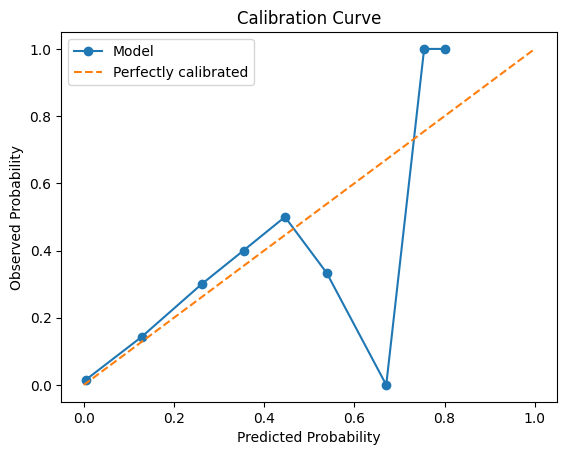

In [30]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Brier score (you already computed earlier, reuse if you have it)
print("Test Brier Score:", test_brier)

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

The test-set Brier score indicates the quality of predicted probabilities.

The calibration curve shows that the predicted probabilities generally follow the diagonal trend, although some deviation is observed.

- Higher predicted probabilities tend to correspond to higher observed bankruptcy rates, indicating useful ranking.
- The model shows slight overconfidence in some probability ranges.
- Even if calibration is not perfect, the model is still effective for ranking risky companies.

## 13. Interpretability

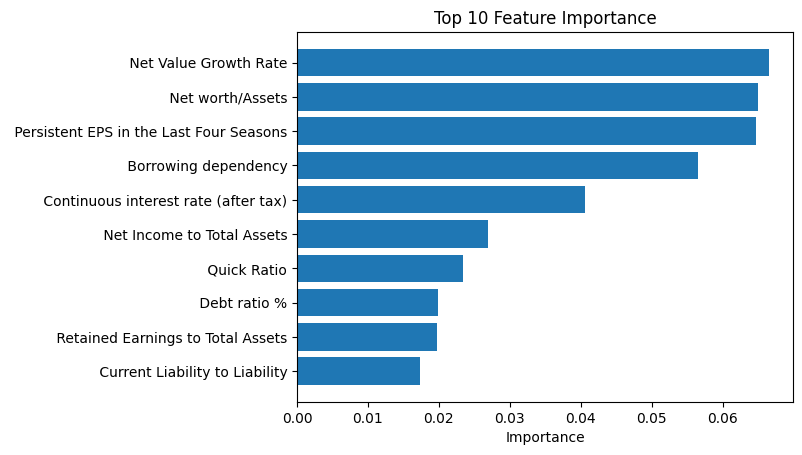

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance = final_model.feature_importances_
features = X_train.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot top 10
plt.figure()
plt.barh(feat_imp["feature"].head(10)[::-1], feat_imp["importance"].head(10)[::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")
plt.show()

The feature importance plot shows which variables contribute most to the model.

- The top feature appears to have a strong influence on predicting bankruptcy risk.
- This result makes sense, as financial indicators are expected to be important for assessing company stability.
- One limitation is that feature importance does not show the direction of the relationship or interactions between variables.

## 12. Conclusion


The XGBoost tuned model was selected as the final model because it achieved the best validation PR-AUC and a strong Brier score, indicating both good discrimination and reasonable probability calibration.

The model performs well in ranking companies by bankruptcy risk, although some overfitting is observed due to the gap between training and validation performance.

The calibration analysis shows that predicted probabilities are generally aligned with actual outcomes, with minor overconfidence in some ranges.

Feature importance results indicate that key financial variables play an important role in prediction, which is consistent with expectations.

Overall, the model is effective for identifying high-risk companies and can support decision-making, even though performance is limited by class imbalance.

## 13. AI Usage Statement

* AI tools were used to assist with coding, debugging, and structuring the notebook.

* The AI helped generate reusable evaluation functions and provided guidance on implementing models and metrics.

* All code generated by AI was reviewed, tested, and modified where necessary to ensure correctness.

* One issue identified during the process was mismatched column names in the results table, which was corrected manually.

* The final implementation and decisions were made based on understanding of the assignment requirements.